# Пульсовой сигнал боковых сборок

## Назначение расчёта

Ноутбук выделяет наблюдаемую ЭКГ-синхронизированную составляющую канала 2 в записях
эксперимента 2. Для каждого добровольца, размера боковой сборки и состояния
дыхания строится робастная ансамблевая форма полного сердечного цикла.

Входами служат принятые интервалы дыхания из `11.01`, принятые R-зубцы из
`11.02` и покардиоцикловый контроль `12.01`. Выход остаётся в исходной шкале
`RHEO2`, мОм. Знак, коэффициент усиления и переход к подписанному изменению
импеданса не установлены. Поэтому этот расчёт не определяет
$\Delta\rho_1$ мягких тканей и $\Delta\rho_2$ лёгкого; их разделение относится
к следующей обратной задаче `33.04`.

Выводы `12.01` предварительно приняты автором для продолжения разработки
методики. Это решение разрешает исследовательский прогон, но не означает
окончательной метрологической или физиологической валидации сигнала.

## Определение ансамблевой формы

Полным сердечным циклом считается интервал от принятого R-зубца до следующего
принятого R-зубца. Каждый такой интервал переводится из времени в безразмерную
фазу от 0 до 1 и интерполируется на сетку из 200 точек. Таким образом, циклы с
разной продолжительностью можно сопоставить без фиксированного окна после
R-зубца. Значение в точке фазы 1 не включается, чтобы в цикл не попадал
следующий R-зубец.

Из каждого цикла вычитается его медианный уровень. Эта операция удаляет только
постоянное смещение и сохраняет форму, размах и знак изменений в шкале
исходного файла. Нулевой уровень полученной кривой не является физическим
нулём изменения импеданса.

Основная ансамблевая форма определяется покоординатной медианой всех циклов,
которые в `12.01` не пересекают предельное плато `RHEO2`. Межквартильный
диапазон показывает внутрисессионную изменчивость формы. Циклы с кандидатной
меткой смещения базовой линии ЭКГ входят в основной ансамбль. Дополнительный
ансамбль без них используется только для оценки чувствительности результата
к этим меткам.

Разные размеры сборок регистрировались последовательно. Поэтому различия их
ансамблей могут отражать одновременно размер, время исследования, состояние
добровольца, контакт электродов и влияние соседнего канала.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REAL_MODE = os.environ.get("KALMYKOV_RUN_REAL", "0") == "1"
CONFIG_ENV = "KALMYKOV_EXP02_CONFIG"
ALGORITHM_VERSION = "series33-pulse-ensemble-v2-rr-normalized"
PHASE_POINT_COUNT = 200
PHASE_GRID = np.linspace(0.0, 1.0, PHASE_POINT_COUNT, endpoint=False)
MODE_LABELS = {
    "задержка_вдох": "после вдоха",
    "задержка_выдох": "после выдоха",
}


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_accepted_sidecars(directory, annotation_type):
    records = {}
    for path in sorted(Path(directory).glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("annotation_type") != annotation_type:
            continue
        if item.get("qc", {}).get("status") != "accepted":
            raise RuntimeError(
                f"Непринятая разметка {annotation_type}: {item.get('record_id')}"
            )
        record_id = item.get("record_id")
        if not record_id or record_id in records:
            raise RuntimeError(f"Некорректный или повторный record_id: {record_id}")
        records[record_id] = (path, item)
    return records


def resolve_under(root, relative_path):
    root = Path(root).resolve()
    resolved = (root / relative_path).resolve()
    resolved.relative_to(root)
    return resolved


def normalized_centered_cycle(time_s, signal_mohm, start_s, stop_s, phase_grid):
    time_s = np.asarray(time_s, dtype=float)
    signal_mohm = np.asarray(signal_mohm, dtype=float)
    phase_grid = np.asarray(phase_grid, dtype=float)
    if len(time_s) != len(signal_mohm) or len(time_s) < 2:
        raise ValueError("Время и сигнал должны иметь одинаковую ненулевую длину")
    if not np.all(np.diff(time_s) > 0):
        raise ValueError("Временная шкала должна строго возрастать")
    start_s = float(start_s)
    stop_s = float(stop_s)
    if not stop_s > start_s:
        raise ValueError("Правая граница сердечного цикла должна быть больше левой")
    if start_s < time_s[0] or stop_s > time_s[-1]:
        raise ValueError("Сердечный цикл выходит за пределы записи")
    sample_times = start_s + phase_grid * (stop_s - start_s)
    sampled = np.interp(sample_times, time_s, signal_mohm)
    if not np.isfinite(sampled).all():
        raise ValueError("В нормированном цикле появились нечисловые значения")
    return sampled - float(np.median(sampled))


def ensemble_statistics(cycles):
    values = np.asarray(cycles, dtype=float)
    if values.ndim != 2 or values.shape[0] < 3:
        raise RuntimeError("Для ансамбля требуется не менее трёх полных циклов")
    return {
        "median": np.median(values, axis=0),
        "q25": np.quantile(values, 0.25, axis=0),
        "q75": np.quantile(values, 0.75, axis=0),
        "n_cycles": int(values.shape[0]),
    }


def iqr(values):
    values = np.asarray(values, dtype=float)
    return float(np.quantile(values, 0.75) - np.quantile(values, 0.25))


plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "figure.dpi": 110,
})

In [2]:
# Синтетическая проверка нормировки и робастного ансамбля
time_test = np.linspace(0.0, 3.0, 3001)
signal_test = np.sin(2.0 * np.pi * time_test)
cycle_test = normalized_centered_cycle(
    time_test, signal_test, 1.0, 2.0, PHASE_GRID
)
assert cycle_test.shape == (PHASE_POINT_COUNT,)
assert abs(float(np.median(cycle_test))) < 1e-12
assert 1.99 < float(np.ptp(cycle_test)) < 2.01

regular = np.stack([cycle_test + shift for shift in (-0.02, -0.01, 0.0, 0.01)])
outlier = cycle_test * 20.0
test_stats = ensemble_statistics(np.vstack([regular, outlier]))
assert np.max(np.abs(test_stats["median"] - cycle_test)) < 0.02
print("Синтетическая проверка нормировки и медианного ансамбля выполнена")

Синтетическая проверка нормировки и медианного ансамбля выполнена


## Расчёт по экспериментальным записям

Код ниже проверяет контрольные суммы исходных файлов и связи между разметками.
Видимый результат содержит только обезличенные агрегаты. Полные
машиночитаемые ансамбли и покардиоцикловые признаки записываются во внешний
каталог исследовательских результатов и не включаются в Git.

In [3]:
if not REAL_MODE:
    print(
        "Расчёт по реальным данным отключён. Для воспроизведения задайте "
        "KALMYKOV_RUN_REAL=1 и KALMYKOV_EXP02_CONFIG."
    )
    ensemble_records = []
    summary_df = pd.DataFrame()
    artifact_path = None
else:
    config_value = os.environ.get(CONFIG_ENV)
    if not config_value:
        raise RuntimeError(f"Не задана переменная {CONFIG_ENV}")
    config_path = Path(config_value).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    data_root = Path(config["data_root"]).expanduser().resolve()
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    breathing_dir = derived_root / "exp02" / "annotations" / "breathing"
    ecg_dir = derived_root / "exp02" / "annotations" / "ecg"
    qc_path = derived_root / "exp02" / "qc" / "12.01_signal_qc.candidate.json"
    if not qc_path.is_file():
        raise FileNotFoundError("Не найден результат 12.01")

    breathing = load_accepted_sidecars(breathing_dir, "breathing")
    ecg = load_accepted_sidecars(ecg_dir, "ecg")
    if set(breathing) != set(ecg):
        raise RuntimeError("Наборы дыхательной и ЭКГ-разметки различаются")

    qc = json.loads(qc_path.read_text(encoding="utf-8"))
    if qc.get("artifact_type") != "post_annotation_signal_qc":
        raise RuntimeError("Файл 12.01 имеет неизвестный тип")
    qc_records = qc.get("records", [])
    expected_records = int(config["expected_independent_record_count"])
    if len(qc_records) != expected_records or len(breathing) != expected_records:
        raise RuntimeError("Число записей не совпадает с паспортом эксперимента")

    subject_labels = {
        item["subject_id"]: item.get("report_label", item["subject_id"])
        for item in config["subjects"]
    }
    rows = []
    ensemble_records = []
    total_cycles = 0
    total_candidate_flags = 0

    for qc_record in qc_records:
        record_id = qc_record["record_id"]
        if record_id not in breathing or record_id not in ecg:
            raise RuntimeError(f"Нет принятой разметки для {record_id}")
        breathing_path, breathing_item = breathing[record_id]
        ecg_path, ecg_item = ecg[record_id]
        source_sha256 = breathing_item["input"]["sha256"]
        if source_sha256 != qc_record["input_sha256"]:
            raise RuntimeError(f"12.01 относится к другой версии CSV: {record_id}")
        if ecg_item["input"]["sha256"] != source_sha256:
            raise RuntimeError(f"ЭКГ относится к другой версии CSV: {record_id}")
        if not qc_record.get("component_use", {}).get("RHEO2", False):
            raise RuntimeError(f"RHEO2 запрещён поканальным решением: {record_id}")

        source_path = resolve_under(
            data_root, breathing_item["input"]["relative_path"]
        )
        if sha256_file(source_path) != source_sha256:
            raise RuntimeError(f"Исходный CSV изменился: {record_id}")
        frame = pd.read_csv(source_path, encoding="utf-8")
        time_s = pd.to_numeric(frame["TIME_s"], errors="raise").to_numpy(float)
        signal_mohm = pd.to_numeric(
            frame["RHEO_2_mΩ"], errors="raise"
        ).to_numpy(float)
        if not np.isfinite(signal_mohm).all():
            raise ValueError(f"RHEO2 содержит нечисловые значения: {record_id}")

        for mode in ("задержка_вдох", "задержка_выдох"):
            selected_cycles = [
                cycle for cycle in qc_record["cycles"]
                if cycle["mode"] == mode and cycle["eligible_without_plateau"]
            ]
            normalized = []
            unflagged = []
            cycle_payload = []
            rr_values = []
            ptp_values = []
            flagged_count = 0
            for cycle in selected_cycles:
                waveform = normalized_centered_cycle(
                    time_s,
                    signal_mohm,
                    cycle["start_r_s"],
                    cycle["stop_r_s"],
                    PHASE_GRID,
                )
                is_flagged = bool(cycle["baseline_artifact_candidate_overlap"])
                normalized.append(waveform)
                if not is_flagged:
                    unflagged.append(waveform)
                flagged_count += int(is_flagged)
                rr_values.append(float(cycle["rr_s"]))
                ptp_values.append(float(np.ptp(waveform)))
                cycle_payload.append({
                    "start_r_s": float(cycle["start_r_s"]),
                    "stop_r_s": float(cycle["stop_r_s"]),
                    "rr_s": float(cycle["rr_s"]),
                    "candidate_ecg_baseline_flag": is_flagged,
                    "centered_native_mohm": waveform.tolist(),
                })

            primary = ensemble_statistics(normalized)
            sensitivity = ensemble_statistics(unflagged)
            primary_ptp = float(np.ptp(primary["median"]))
            maximum_difference = float(
                np.max(np.abs(primary["median"] - sensitivity["median"]))
            )
            relative_difference = (
                100.0 * maximum_difference / primary_ptp
                if primary_ptp > 0 else np.nan
            )
            subject_id = breathing_item["subject_id"]
            size_mm = int(breathing_item["size_mm"])
            total_cycles += primary["n_cycles"]
            total_candidate_flags += flagged_count
            rows.append({
                "доброволец": subject_labels[subject_id],
                "размер, мм": size_mm,
                "состояние": MODE_LABELS[mode],
                "циклов": primary["n_cycles"],
                "с меткой ЭКГ": flagged_count,
                "медиана R–R, с": float(np.median(rr_values)),
                "МКР R–R, с": iqr(rr_values),
                "медиана размаха цикла, мОм": float(np.median(ptp_values)),
                "размах ансамбля, мОм": primary_ptp,
                "влияние меток, мОм": maximum_difference,
                "влияние меток, % размаха": relative_difference,
            })
            ensemble_records.append({
                "record_id": record_id,
                "subject_id": subject_id,
                "size_mm": size_mm,
                "mode": mode,
                "signal_column": "RHEO_2_mΩ",
                "signal_unit": "mOhm_native_file_scale",
                "phase_rr": PHASE_GRID.tolist(),
                "primary": {
                    "definition": "all_cycles_without_extreme_plateau",
                    "median_mohm": primary["median"].tolist(),
                    "q25_mohm": primary["q25"].tolist(),
                    "q75_mohm": primary["q75"].tolist(),
                    "n_cycles": primary["n_cycles"],
                },
                "sensitivity_without_candidate_ecg_flags": {
                    "median_mohm": sensitivity["median"].tolist(),
                    "q25_mohm": sensitivity["q25"].tolist(),
                    "q75_mohm": sensitivity["q75"].tolist(),
                    "n_cycles": sensitivity["n_cycles"],
                    "maximum_absolute_difference_mohm": maximum_difference,
                    "difference_relative_to_primary_ptp_percent": relative_difference,
                },
                "cycles": cycle_payload,
                "input_provenance": {
                    "input_sha256": source_sha256,
                    "breathing_sidecar_sha256": sha256_file(breathing_path),
                    "ecg_sidecar_sha256": sha256_file(ecg_path),
                },
            })

    expected_ensembles = expected_records * 2
    if len(ensemble_records) != expected_ensembles:
        raise RuntimeError(
            f"Получено {len(ensemble_records)} ансамблей вместо {expected_ensembles}"
        )
    summary_df = pd.DataFrame(rows).sort_values(
        ["доброволец", "размер, мм", "состояние"]
    ).reset_index(drop=True)
    numeric_columns = [
        "медиана R–R, с", "МКР R–R, с",
        "медиана размаха цикла, мОм", "размах ансамбля, мОм",
        "влияние меток, мОм", "влияние меток, % размаха",
    ]
    summary_df[numeric_columns] = summary_df[numeric_columns].round(3)

    artifact = {
        "schema_version": 2,
        "analysis": "33.03_rr_normalized_pulse_ensembles",
        "algorithm_version": ALGORITHM_VERSION,
        "status": "exploratory_hypothesis_not_validated",
        "created_at": datetime.now(timezone.utc).isoformat(),
        "author_decision": {
            "status": "provisionally_accepted_for_method_development",
            "date": "2026-08-28",
            "scope": "12.01 cycle selection and candidate-flag policy",
        },
        "upstream": {
            "12.01_status": qc.get("status"),
            "12.01_sha256": sha256_file(qc_path),
            "breathing_annotation_status": "accepted",
            "ecg_annotation_status": "accepted",
        },
        "signal_semantics": {
            "column": "RHEO_2_mΩ",
            "unit": "mOhm_native_file_scale",
            "gain": "unknown_not_applied",
            "physical_sign": "unknown_native_sign_preserved",
            "offset": "per_cycle_median_removed",
            "timing_calibration": "not_measured",
        },
        "algorithm": {
            "cycle": "accepted_R_to_next_accepted_R",
            "phase_grid_point_count": PHASE_POINT_COUNT,
            "phase_endpoint_included": False,
            "primary_center": "per_cycle_median",
            "primary_ensemble": "pointwise_median",
            "dispersion": "pointwise_interquartile_range",
            "candidate_ecg_flags_excluded_from_primary": False,
        },
        "limitations": [
            "different_sizes_recorded_sequentially",
            "native_instrument_scale_not_calibrated_delta_impedance",
            "physical_signal_sign_unknown",
            "ecg_synchrony_does_not_localize_signal_source",
            "within_record_cycles_are_not_independent_experiments",
            "rr_phase_normalization_removes_absolute_cycle_duration_from_waveform_axis",
        ],
        "summary": {
            "record_count": expected_records,
            "ensemble_count": len(ensemble_records),
            "cycle_count": total_cycles,
            "candidate_ecg_flag_cycle_count": total_candidate_flags,
        },
        "ensembles": ensemble_records,
    }
    out_dir = derived_root / "exp02" / "exploratory"
    out_dir.mkdir(parents=True, exist_ok=True)
    artifact_path = out_dir / "33.03_pulse_ensembles.provisional.json"
    temporary_path = artifact_path.with_suffix(artifact_path.suffix + ".tmp")
    temporary_path.write_text(
        json.dumps(artifact, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    temporary_path.replace(artifact_path)
    print(
        f"Обработано записей: {expected_records}; ансамблей: "
        f"{len(ensemble_records)}; сердечных циклов: {total_cycles}; "
        f"циклов с кандидатной меткой ЭКГ: {total_candidate_flags}"
    )
    print("Внешний исследовательский результат:", artifact_path.name)

Обработано записей: 19; ансамблей: 38; сердечных циклов: 776; циклов с кандидатной меткой ЭКГ: 50
Внешний исследовательский результат: 33.03_pulse_ensembles.provisional.json


## Наблюдаемые характеристики ансамблей

Таблица содержит характеристики измеренного сигнала в шкале исходного файла.
В столбце «МКР R–R» приведён межквартильный размах длительности цикла.
«Размах ансамбля» равен разности максимума и минимума медианной формы.
«Влияние меток» — максимальное по фазе различие между основным ансамблем и
диагностическим ансамблем без циклов с кандидатной меткой ЭКГ. Эта величина
оценивает устойчивость результата к спорным циклам, но не является
доверительным интервалом или полной погрешностью.

На графиках сплошная линия показывает основной медианный ансамбль, область
вокруг неё — межквартильный диапазон, а штриховая линия — диагностический
вариант без кандидатных меток ЭКГ.

,доброволец,"размер, мм",состояние,циклов,с меткой ЭКГ,"медиана R–R, с","МКР R–R, с","медиана размаха цикла, мОм","размах ансамбля, мОм","влияние меток, мОм","влияние меток, % размаха"
0,Георг,50,после вдоха,21,0,1.14,0.120,49.886,36.332,0.000,0.000
1,Георг,50,после выдоха,26,0,0.71,0.040,58.738,50.055,0.000,0.000
2,Георг,60,после вдоха,18,3,1.07,0.170,73.123,46.515,10.950,23.540
3,Георг,60,после выдоха,21,0,0.76,0.125,71.488,49.438,0.000,0.000
4,Георг,70,после вдоха,13,0,1.06,0.160,55.531,33.885,0.000,0.000
5,Георг,70,после выдоха,24,0,0.77,0.040,72.393,54.828,0.000,0.000
6,Георг,80,после вдоха,13,0,1.10,0.080,57.383,41.889,0.000,0.000
7,Георг,80,после выдоха,21,0,0.74,0.060,99.683,84.434,0.000,0.000
8,Георг,90,после вдоха,16,0,1.00,0.045,51.930,33.936,0.000,0.000
9,Георг,90,после выдоха,19,0,0.70,0.050,90.747,80.130,0.000,0.000


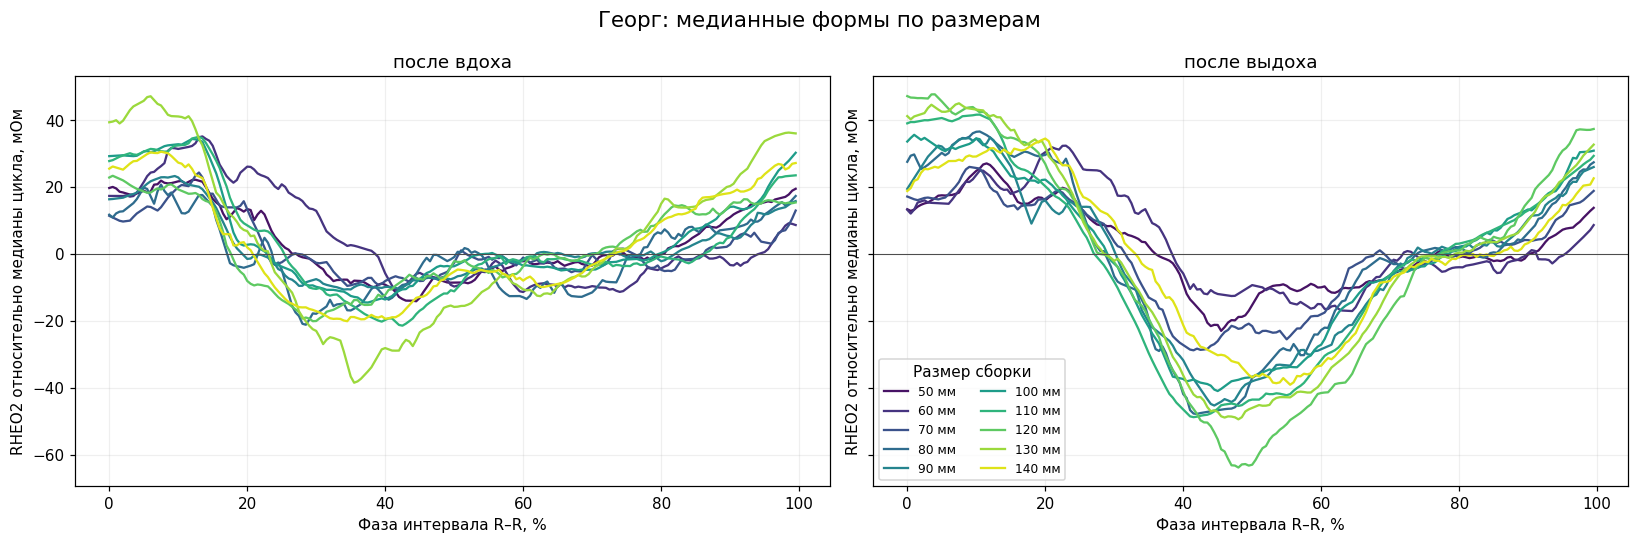

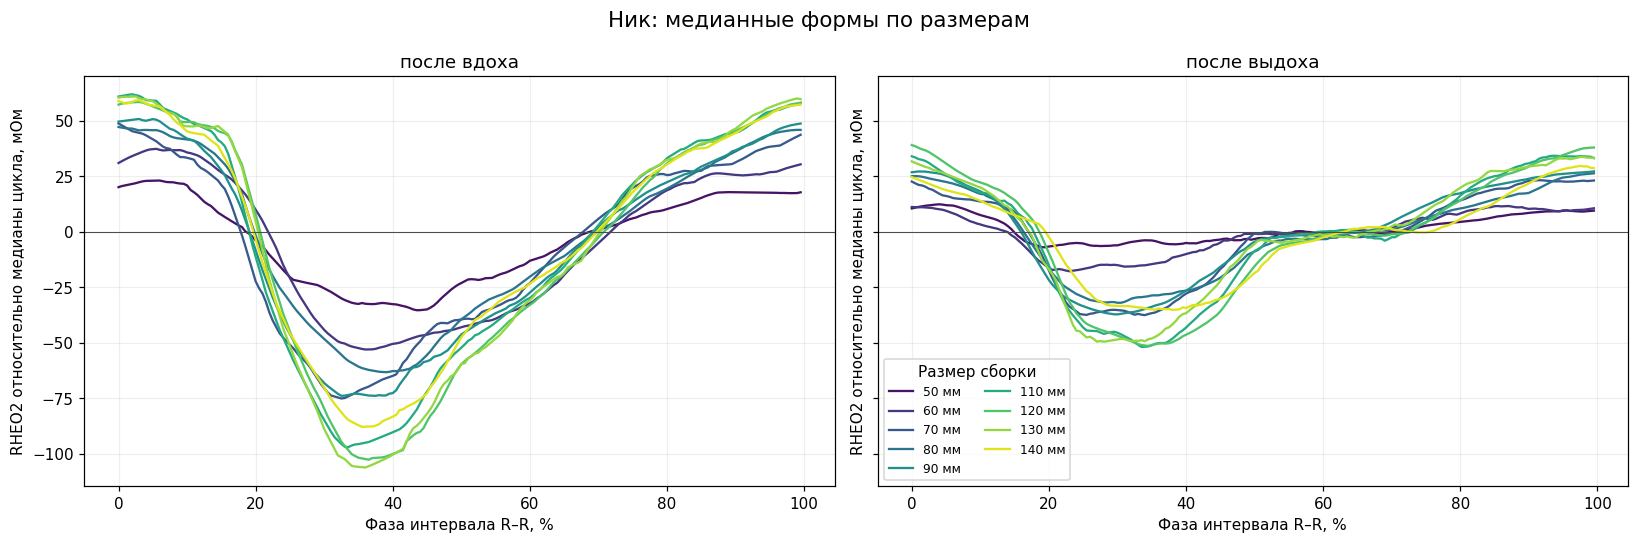

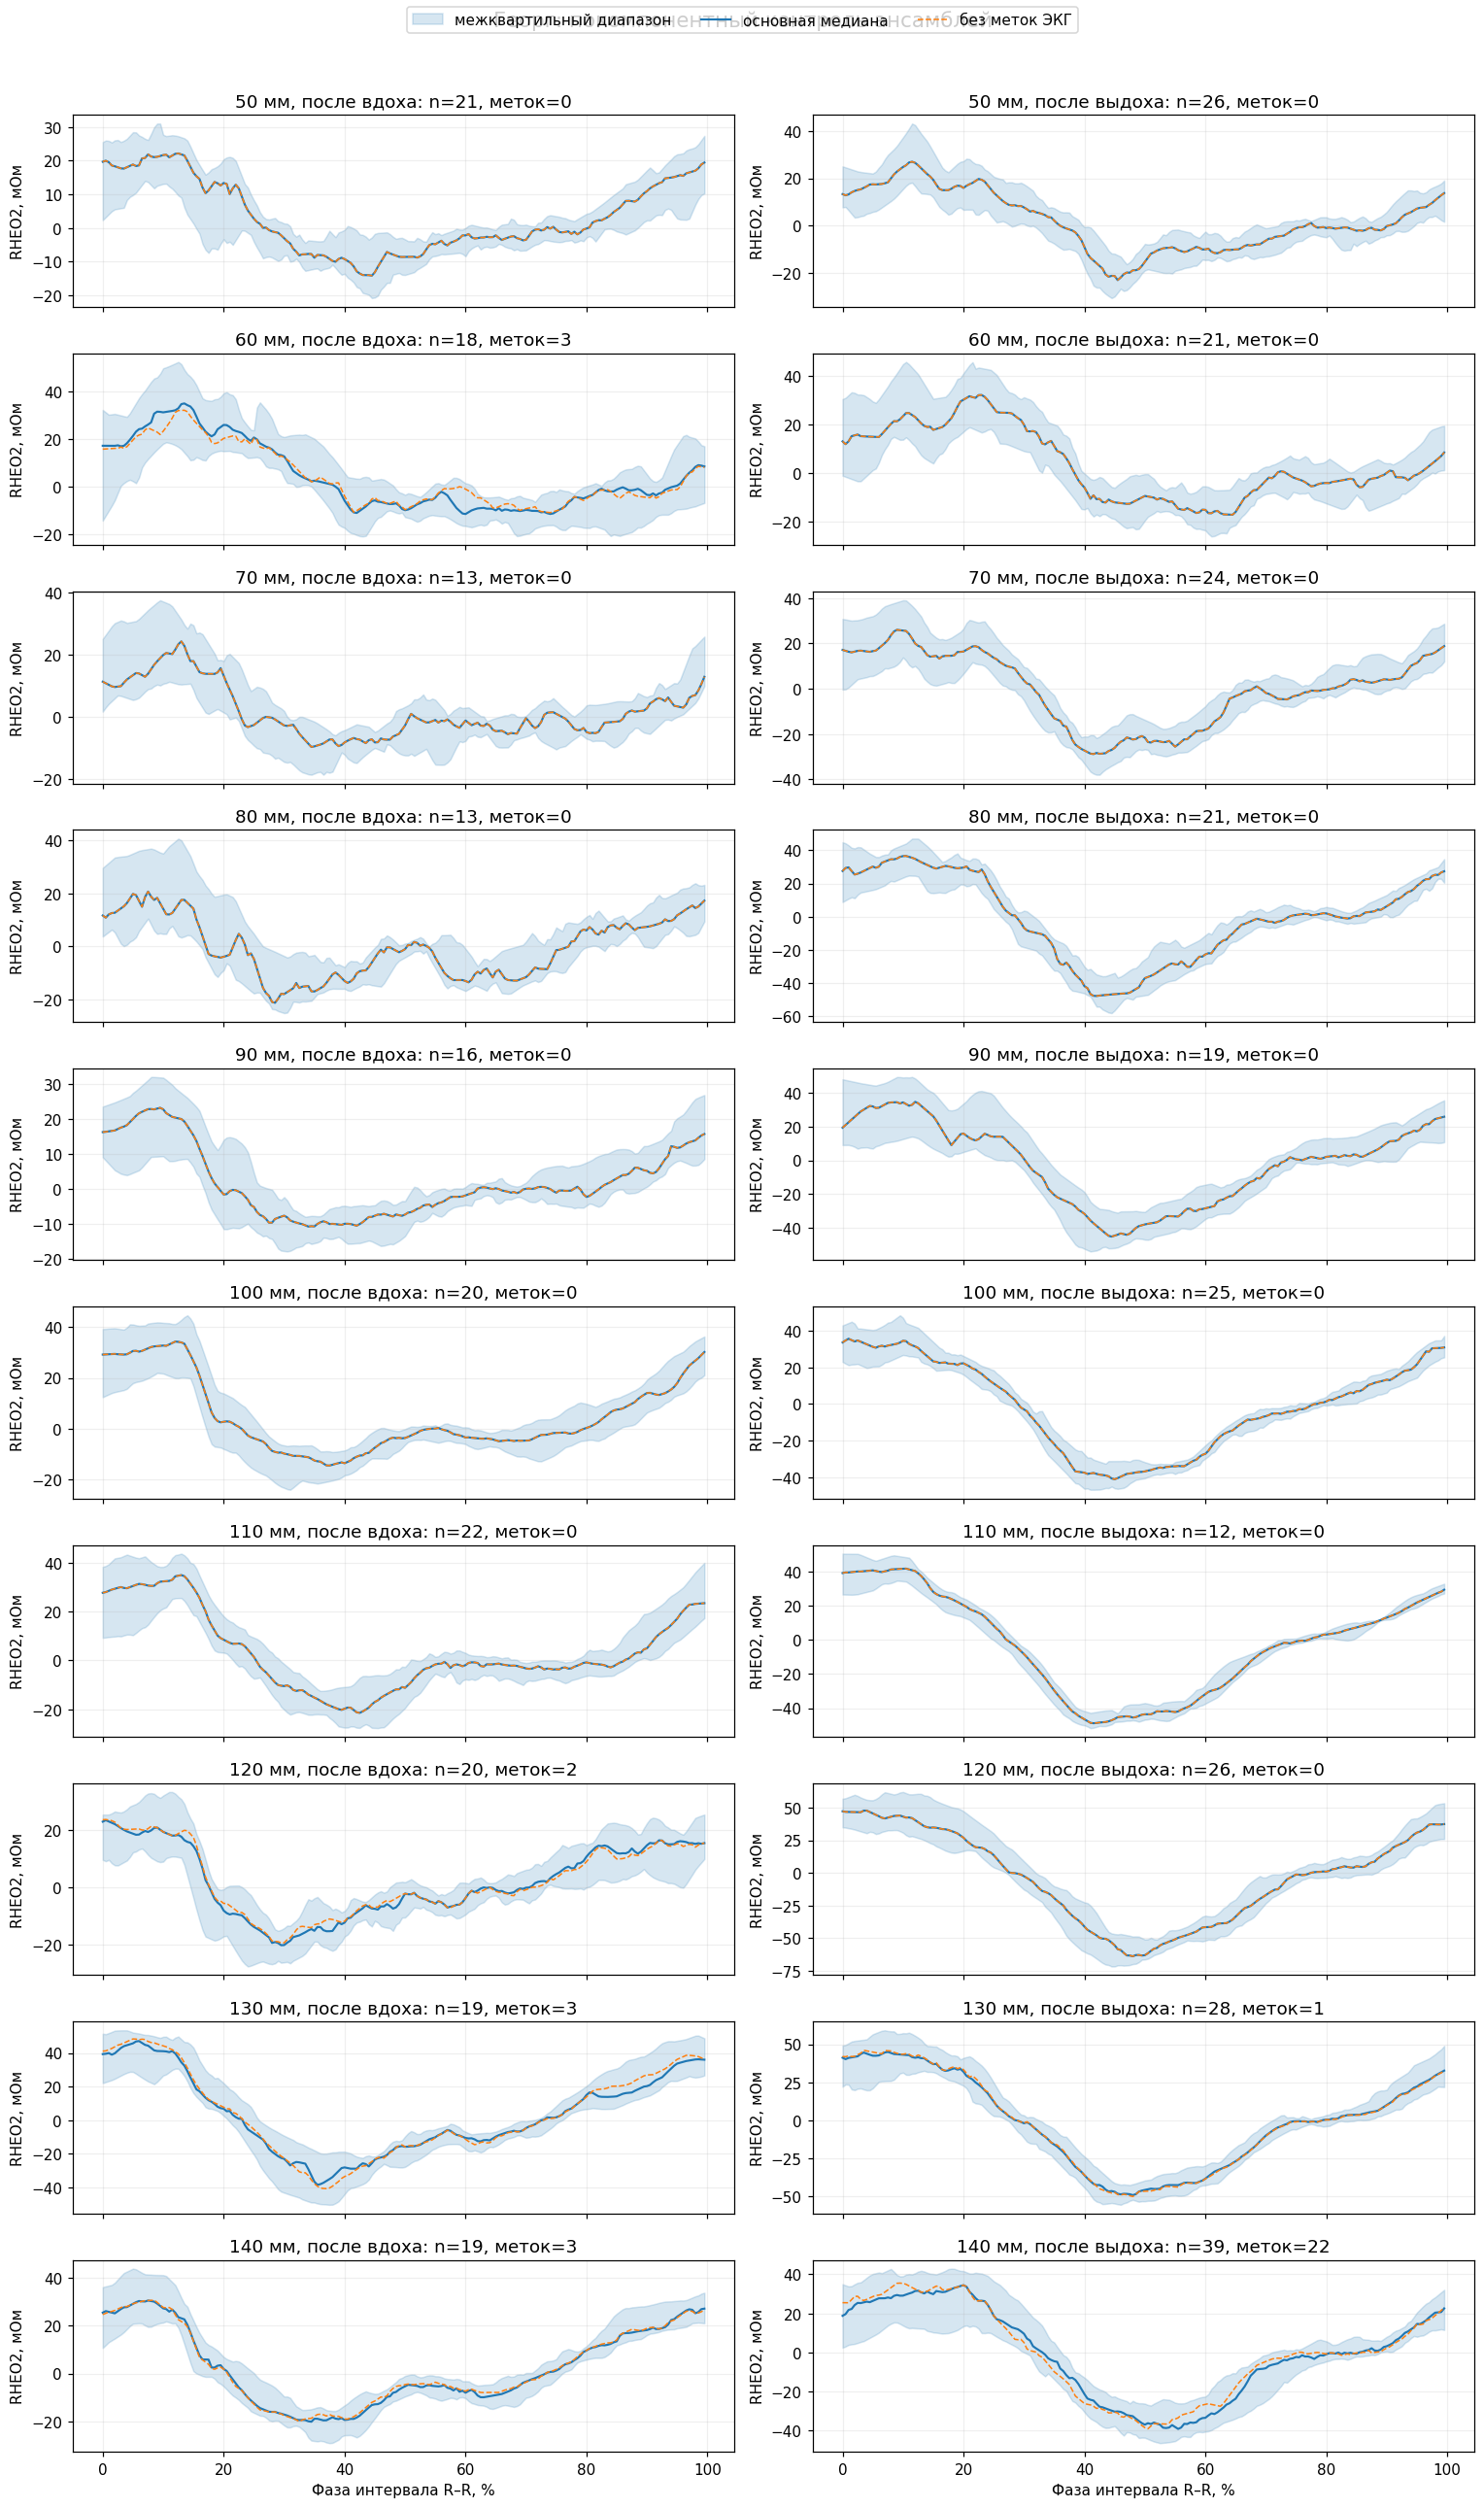

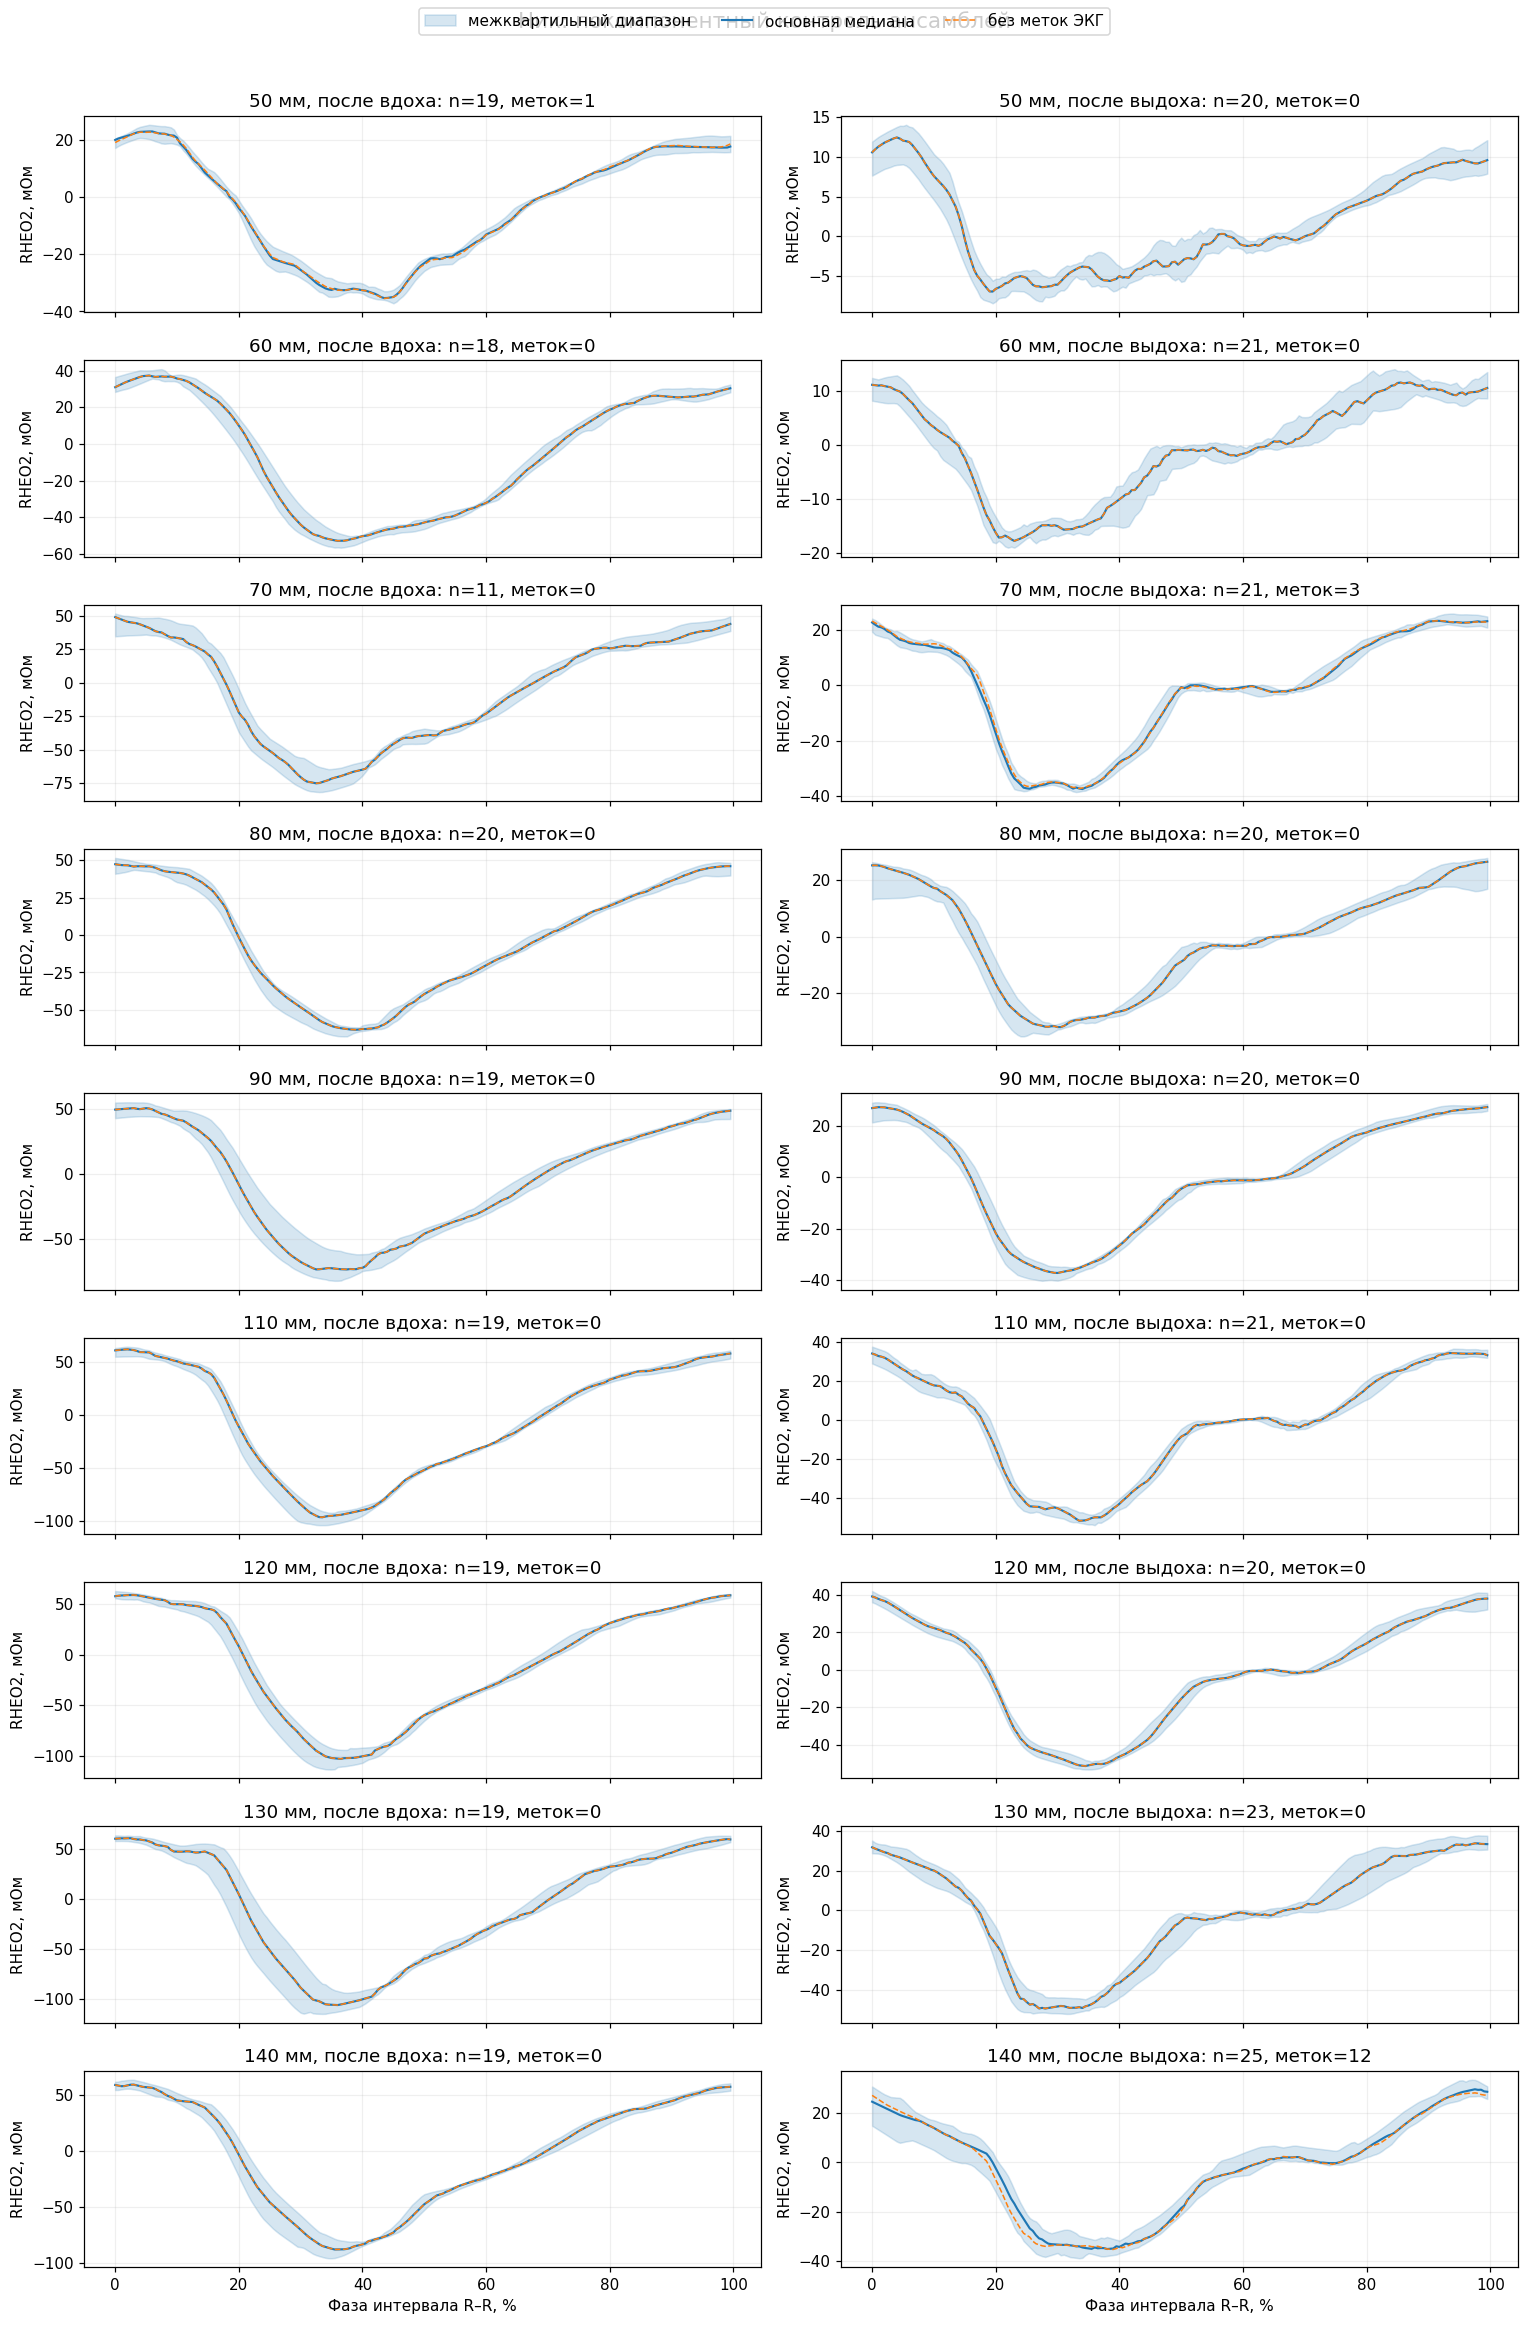

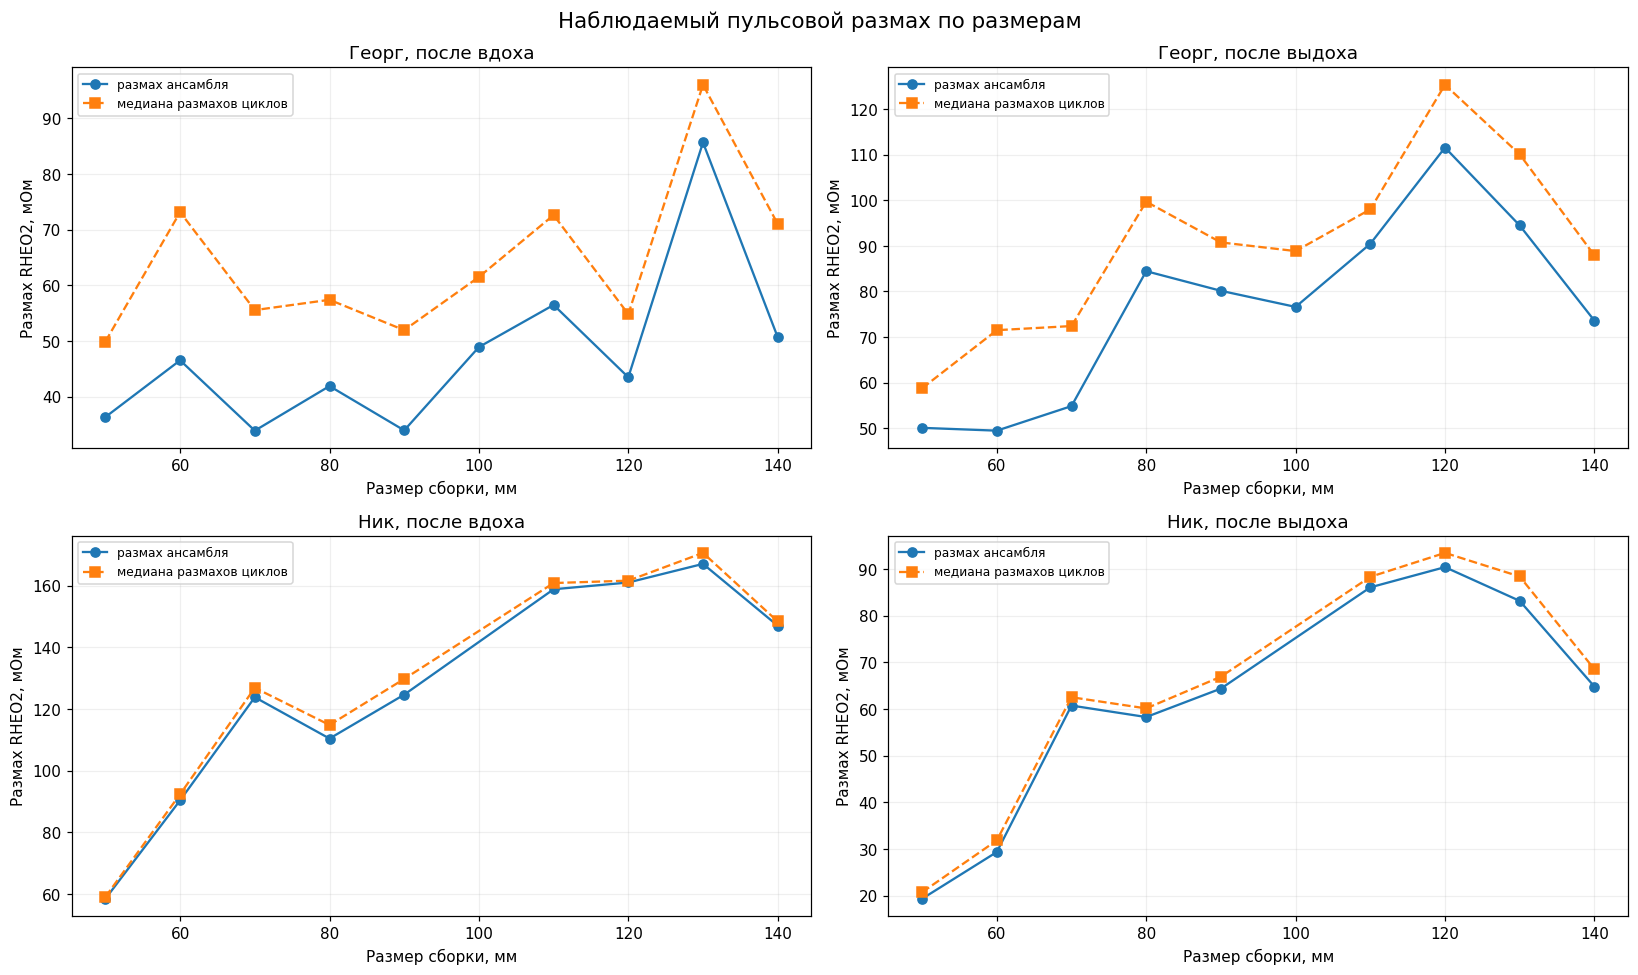

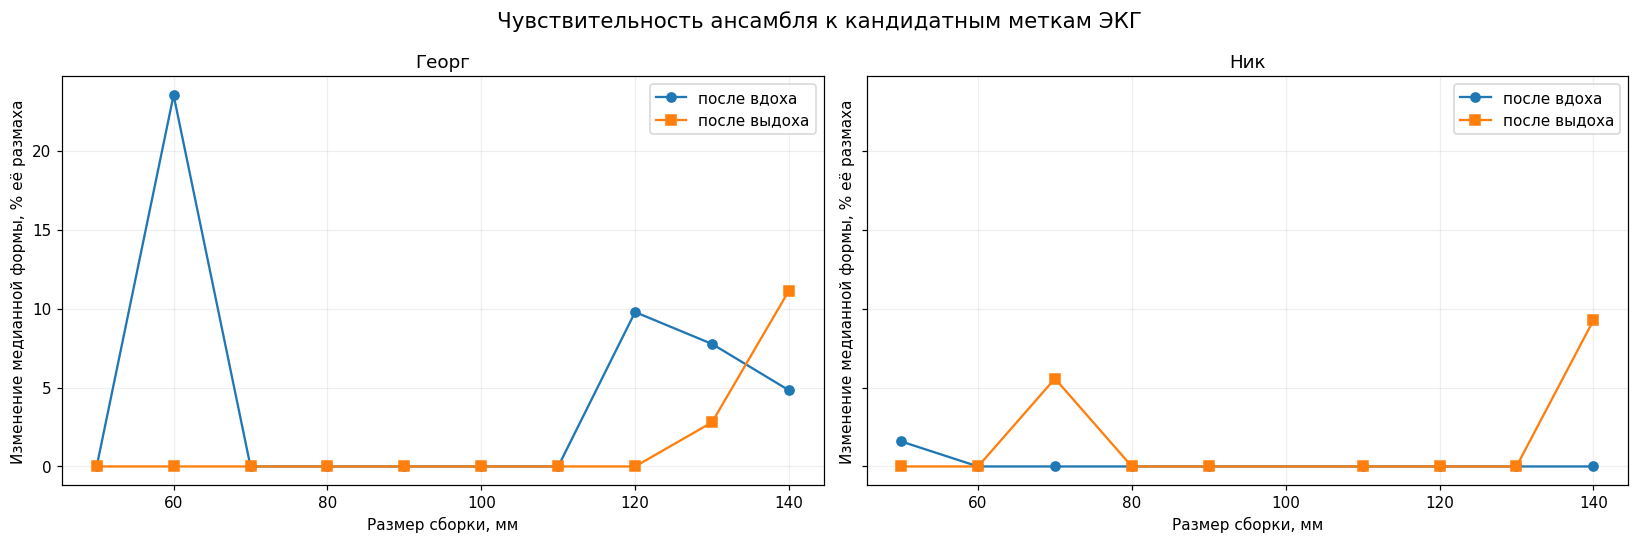

In [4]:
if REAL_MODE:
    display(summary_df)

    ensemble_index = {
        (item["subject_id"], item["size_mm"], item["mode"]): item
        for item in ensemble_records
    }
    sizes_by_subject = {
        subject_id: sorted({
            item["size_mm"] for item in ensemble_records
            if item["subject_id"] == subject_id
        })
        for subject_id in subject_labels
    }

    for subject_id in ("exp02_georg", "exp02_nik"):
        sizes = sizes_by_subject[subject_id]
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
        colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(sizes)))
        for axis, mode in zip(axes, MODE_LABELS):
            for color, size_mm in zip(colors, sizes):
                item = ensemble_index[(subject_id, size_mm, mode)]
                axis.plot(
                    100.0 * PHASE_GRID,
                    item["primary"]["median_mohm"],
                    color=color,
                    linewidth=1.5,
                    label=f"{size_mm} мм",
                )
            axis.axhline(0.0, color="0.3", linewidth=0.7)
            axis.set_title(MODE_LABELS[mode])
            axis.set_xlabel("Фаза интервала R–R, %")
            axis.set_ylabel("RHEO2 относительно медианы цикла, мОм")
        axes[-1].legend(ncol=2, fontsize=8, title="Размер сборки")
        fig.suptitle(
            f"{subject_labels[subject_id]}: медианные формы по размерам",
            fontsize=14,
        )
        fig.tight_layout()
        plt.show()

    for subject_id in ("exp02_georg", "exp02_nik"):
        sizes = sizes_by_subject[subject_id]
        fig, axes = plt.subplots(
            len(sizes), 2, figsize=(14, 2.35 * len(sizes)), sharex=True
        )
        for row_index, size_mm in enumerate(sizes):
            for column_index, mode in enumerate(MODE_LABELS):
                axis = axes[row_index, column_index]
                item = ensemble_index[(subject_id, size_mm, mode)]
                primary = item["primary"]
                sensitivity = item["sensitivity_without_candidate_ecg_flags"]
                x = 100.0 * PHASE_GRID
                axis.fill_between(
                    x, primary["q25_mohm"], primary["q75_mohm"],
                    color="tab:blue", alpha=0.18, label="межквартильный диапазон",
                )
                axis.plot(
                    x, primary["median_mohm"], color="tab:blue",
                    linewidth=1.4, label="основная медиана",
                )
                axis.plot(
                    x, sensitivity["median_mohm"], color="tab:orange",
                    linewidth=1.0, linestyle="--", label="без меток ЭКГ",
                )
                flagged = primary["n_cycles"] - sensitivity["n_cycles"]
                axis.set_title(
                    f"{size_mm} мм, {MODE_LABELS[mode]}: "
                    f"n={primary['n_cycles']}, меток={flagged}"
                )
                axis.set_ylabel("RHEO2, мОм")
        axes[-1, 0].set_xlabel("Фаза интервала R–R, %")
        axes[-1, 1].set_xlabel("Фаза интервала R–R, %")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=3)
        fig.suptitle(
            f"{subject_labels[subject_id]}: покомпонентный контроль ансамблей",
            fontsize=14,
            y=0.997,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.985))
        plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=False)
    for row_index, subject_id in enumerate(("exp02_georg", "exp02_nik")):
        subset = summary_df[summary_df["доброволец"] == subject_labels[subject_id]]
        for column_index, mode_label in enumerate(MODE_LABELS.values()):
            axis = axes[row_index, column_index]
            selected = subset[subset["состояние"] == mode_label]
            axis.plot(
                selected["размер, мм"],
                selected["размах ансамбля, мОм"],
                "o-", label="размах ансамбля",
            )
            axis.plot(
                selected["размер, мм"],
                selected["медиана размаха цикла, мОм"],
                "s--", label="медиана размахов циклов",
            )
            axis.set_title(f"{subject_labels[subject_id]}, {mode_label}")
            axis.set_xlabel("Размер сборки, мм")
            axis.set_ylabel("Размах RHEO2, мОм")
            axis.legend(fontsize=8)
    fig.suptitle("Наблюдаемый пульсовой размах по размерам", fontsize=14)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for axis, subject_id in zip(axes, ("exp02_georg", "exp02_nik")):
        subset = summary_df[summary_df["доброволец"] == subject_labels[subject_id]]
        for mode_label, marker in zip(MODE_LABELS.values(), ("o", "s")):
            selected = subset[subset["состояние"] == mode_label]
            axis.plot(
                selected["размер, мм"],
                selected["влияние меток, % размаха"],
                marker=marker,
                label=mode_label,
            )
        axis.set_title(subject_labels[subject_id])
        axis.set_xlabel("Размер сборки, мм")
        axis.set_ylabel("Изменение медианной формы, % её размаха")
        axis.legend()
    fig.suptitle(
        "Чувствительность ансамбля к кандидатным меткам ЭКГ", fontsize=14
    )
    fig.tight_layout()
    plt.show()

In [5]:
if REAL_MODE:
    maximum_row = summary_df.loc[
        summary_df["влияние меток, % размаха"].idxmax()
    ]
    georg_overlap = int(
        sum(
            cycle["fixed_window_overlaps_next_r"]
            for record in qc_records
            if record["subject_id"] == "exp02_georg"
            for cycle in record["cycles"]
        )
    )
    nik_overlap = int(
        sum(
            cycle["fixed_window_overlaps_next_r"]
            for record in qc_records
            if record["subject_id"] == "exp02_nik"
            for cycle in record["cycles"]
        )
    )
    breathing_comparison = summary_df.pivot_table(
        index=["доброволец", "размер, мм"],
        columns="состояние",
        values="размах ансамбля, мОм",
    )
    georg_comparison = breathing_comparison.loc[subject_labels["exp02_georg"]]
    nik_comparison = breathing_comparison.loc[subject_labels["exp02_nik"]]
    georg_exhale_larger = bool(
        (georg_comparison["после выдоха"] > georg_comparison["после вдоха"]).all()
    )
    nik_inhale_larger = bool(
        (nik_comparison["после вдоха"] > nik_comparison["после выдоха"]).all()
    )
    if georg_exhale_larger and nik_inhale_larger:
        breathing_result = (
            "Для всех зарегистрированных размеров у Георга размах после выдоха "
            "больше размаха после вдоха, а у Ника наблюдается противоположное "
            "соотношение. Направление дыхательного различия не совпадает у двух "
            "добровольцев."
        )
    else:
        breathing_result = (
            "Направление различия между задержками после вдоха и после выдоха "
            "не является единообразным для всех размеров и добровольцев."
        )
    peak_rows = summary_df.loc[
        summary_df.groupby(["доброволец", "состояние"])[
            "размах ансамбля, мОм"
        ].idxmax()
    ]
    peak_text = "; ".join(
        f"{row['доброволец']}, {row['состояние']} — {int(row['размер, мм'])} мм"
        for _, row in peak_rows.iterrows()
    )
    minimum_phases = [
        float(100.0 * PHASE_GRID[int(np.argmin(item["primary"]["median_mohm"]))])
        for item in ensemble_records
    ]
    minimum_phase_text = (
        f"{min(minimum_phases):.1f}–{max(minimum_phases):.1f}"
    ).replace(".", ",")
    maximum_influence_text = (
        f"{maximum_row['влияние меток, % размаха']:.1f}"
    ).replace(".", ",")
    display(Markdown(f"""## Результат извлечения пульсового сигнала

Для 19 независимых записей построено {len(ensemble_records)} ансамблей:
отдельно для задержки после вдоха и задержки после выдоха. В основной расчёт
вошло {total_cycles} полных сердечных циклов. {total_candidate_flags} циклов с
кандидатной меткой ЭКГ сохранены и отмечены в диагностическом сравнении.

Нормировка полного интервала R–R устранила установленную в `12.01` проблему
фиксированного окна: окно длительностью 0,7 с захватывало следующий R-зубец в
{georg_overlap} циклах Георга и {nik_overlap} циклах Ника. В текущем расчёте
следующий цикл не включается по определению фазовой сетки.

После вычитания медианного уровня все ансамблевые формы содержат
выраженную отрицательную волну относительно R-зубца. Минимум медианной формы
расположен в диапазоне {minimum_phase_text} % интервала R–R.
Физический знак этого отклонения пока неизвестен, поэтому минимум нельзя
интерпретировать как максимум или минимум кровенаполнения.

Покомпонентные графики показывают устойчивую неслучайную форму относительно
R-зубца, особенно в записях Ника. Такая повторяемость позволяет выделить
ЭКГ-синхронизированную составляющую внутри каждой записи. Она сама по себе не
доказывает физиологическое происхождение: в форму могут входить пульсовой
ответ тканей, межканальное влияние и повторяемый приборный отклик.

{breathing_result} Это наблюдение относится к двум добровольцам и к
последовательной регистрации размерного ряда у каждого из них. Оно не
устанавливает физиологическую или приборную причину различия.

Наибольший наблюдаемый размах получен для следующих размеров: {peak_text}.
Эти точки не являются автоматически оптимальными размерами сборок: для
каждого размера имеется по одной записи, выполненной в фиксированной
последовательности, а зависимость Георга заметно немонотонна.

Наибольшее относительное изменение медианной формы после диагностического
удаления циклов с меткой ЭКГ равно
{maximum_influence_text} % для добровольца
{maximum_row['доброволец']}, сборки {int(maximum_row['размер, мм'])} мм,
{maximum_row['состояние']}. Эта величина характеризует только чувствительность
к выбранным меткам и не является оценкой полной погрешности.

Полученные кривые являются наблюдаемыми ансамблями `RHEO2` в исходных мОм.
Привязка ансамблей к R-зубцам устанавливает сердечную синхронность, но не
разделяет вклад мягких тканей и лёгкого и не определяет физический знак
сигнала.
"""))

## Результат извлечения пульсового сигнала

Для 19 независимых записей построено 38 ансамблей:
отдельно для задержки после вдоха и задержки после выдоха. В основной расчёт
вошло 776 полных сердечных циклов. 50 циклов с
кандидатной меткой ЭКГ сохранены и отмечены в диагностическом сравнении.

Нормировка полного интервала R–R устранила установленную в `12.01` проблему
фиксированного окна: окно длительностью 0,7 с захватывало следующий R-зубец в
65 циклах Георга и 0 циклах Ника. В текущем расчёте
следующий цикл не включается по определению фазовой сетки.

После вычитания медианного уровня все ансамблевые формы содержат
выраженную отрицательную волну относительно R-зубца. Минимум медианной формы
расположен в диапазоне 19,5–64,5 % интервала R–R.
Физический знак этого отклонения пока неизвестен, поэтому минимум нельзя
интерпретировать как максимум или минимум кровенаполнения.

Покомпонентные графики показывают устойчивую неслучайную форму относительно
R-зубца, особенно в записях Ника. Такая повторяемость позволяет выделить
ЭКГ-синхронизированную составляющую внутри каждой записи. Она сама по себе не
доказывает физиологическое происхождение: в форму могут входить пульсовой
ответ тканей, межканальное влияние и повторяемый приборный отклик.

Для всех зарегистрированных размеров у Георга размах после выдоха больше размаха после вдоха, а у Ника наблюдается противоположное соотношение. Направление дыхательного различия не совпадает у двух добровольцев. Это наблюдение относится к двум добровольцам и к
последовательной регистрации размерного ряда у каждого из них. Оно не
устанавливает физиологическую или приборную причину различия.

Наибольший наблюдаемый размах получен для следующих размеров: Георг, после вдоха — 130 мм; Георг, после выдоха — 120 мм; Ник, после вдоха — 130 мм; Ник, после выдоха — 120 мм.
Эти точки не являются автоматически оптимальными размерами сборок: для
каждого размера имеется по одной записи, выполненной в фиксированной
последовательности, а зависимость Георга заметно немонотонна.

Наибольшее относительное изменение медианной формы после диагностического
удаления циклов с меткой ЭКГ равно
23,5 % для добровольца
Георг, сборки 60 мм,
после вдоха. Эта величина характеризует только чувствительность
к выбранным меткам и не является оценкой полной погрешности.

Полученные кривые являются наблюдаемыми ансамблями `RHEO2` в исходных мОм.
Привязка ансамблей к R-зубцам устанавливает сердечную синхронность, но не
разделяет вклад мягких тканей и лёгкого и не определяет физический знак
сигнала.


## Передача результата в обратную задачу

В `33.04` передаются фазовая сетка, медианная форма, межквартильный диапазон,
число циклов и диагностическая оценка влияния кандидатных меток для каждого
добровольца, размера и состояния дыхания. Переход к
$\Delta\rho_1$ и $\Delta\rho_2$ потребует отдельного оператора прямой модели,
её локальных чувствительностей и явного сценария неизвестной калибровки.

До такой проверки нельзя интерпретировать размах `RHEO2` как изменение
удельного сопротивления конкретной ткани. Сердечная синхронность определяет
временную связь сигнала, но не место его возникновения. Межразмерные различия
также нельзя объяснять только геометрией сборки, поскольку размеры
регистрировались последовательно.

Фазовая нормировка предполагает сопоставимость одинаковых долей разных
интервалов R–R. Если физиологическая задержка изменяется в секундах не
пропорционально длительности цикла, такая нормировка смещает её положение на
фазовой оси. Поэтому временные задержки в миллисекундах должны рассчитываться
в `33.05` по исходной временной шкале каждого цикла, а не по медианной фазовой
кривой `33.03`.

Полный результат сохраняется как исследовательский артефакт разработки
методики. Он может использоваться для проверки постановки `33.04`, но
полученные числа пока не являются валидированными физиологическими оценками.